# 12. Regresja logistyczna: porównywanie modeli, deviance, pseudo-$R^2$ i testy współczynników

Ten notebook rozwija część o likelihoodach. W regresji logistycznej najczęściej porównujemy modele przez log-likelihood i deviance, a nie przez $SSE$.

Najważniejsze obiekty:

$$
\ell(\beta)=\sum_i \left[y_i\eta_i - \log(1+e^{\eta_i})\right]
$$

$$
Deviance = -2(\ell_{model}-\ell_{saturated})
$$

Dla indywidualnych obserwacji Bernoulliego model nasycony może mieć $\ell_{saturated}=0$, więc:

$$
Deviance = -2\ell_{model}
$$

Porównanie modeli zagnieżdżonych:

$$
G^2 = Deviance_{reduced}-Deviance_{full}=2(\ell_{full}-\ell_{reduced})
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm

pd.set_option('display.precision', 6)

In [2]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -35, 35)
    return 1 / (1 + np.exp(-z))


def loglik_logistic(beta, X, y):
    eta = X @ beta
    return float(np.sum(y * eta - np.logaddexp(0, eta)))


def fit_logistic_irls(X, y, l2=0.0, max_iter=150, tol=1e-10):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    beta = np.zeros(k)
    penalty = np.eye(k)
    penalty[0, 0] = 0.0
    converged = False
    for iteration in range(max_iter):
        eta = X @ beta
        p = sigmoid(eta)
        W = p * (1 - p)
        gradient = X.T @ (y - p) - l2 * (penalty @ beta)
        information = (X.T * W) @ X + l2 * penalty
        step = np.linalg.pinv(information) @ gradient
        beta_new = beta + step
        if np.max(np.abs(step)) < tol:
            beta = beta_new
            converged = True
            break
        beta = beta_new
    eta = X @ beta
    p = sigmoid(eta)
    W = p * (1 - p)
    information = (X.T * W) @ X + l2 * penalty
    cov_beta = np.linalg.pinv(information)
    se_beta = np.sqrt(np.diag(cov_beta))
    return {
        'beta': beta,
        'se': se_beta,
        'cov': cov_beta,
        'll': loglik_logistic(beta, X, y),
        'p_hat': p,
        'converged': converged,
        'iterations': iteration + 1,
    }


def fit_named_model(df, y_col, columns, l2=0.0):
    X_parts = [np.ones(len(df))]
    names = ['intercept']
    for col in columns:
        X_parts.append(df[col].to_numpy())
        names.append(col)
    X = np.column_stack(X_parts)
    y = df[y_col].to_numpy()
    fit = fit_logistic_irls(X, y, l2=l2)
    return X, y, names, fit

## 1. Dane: ekspresja genu, masa myszy, mutacja i choroba

To mały syntetyczny przykład do pokazania idei. Mamy trzy potencjalne predyktory:

- `expression`: ekspresja genu,
- `weight`: masa myszy,
- `mutated`: informacja 0/1, czy gen jest zmutowany.

Cel: przewidzieć `disease`.

In [3]:
rng = np.random.default_rng(7)
n = 36
weight = rng.normal(22, 3.0, n).round(1)
mutated = rng.binomial(1, 0.42, n)
expression = (1.2 + 0.08*weight + 0.55*mutated + rng.normal(0, 0.35, n)).round(2)
eta_true = -5.6 + 1.25*expression + 0.75*mutated + 0.015*weight
p_true = sigmoid(eta_true)
disease = rng.binomial(1, p_true)

# Bezpiecznik: gdyby losowanie dało zbyt mało jednej klasy, deterministycznie korygujemy kilka wartości.
if disease.sum() < 6:
    disease[np.argsort(p_true)[-6:]] = 1
if (1 - disease).sum() < 6:
    disease[np.argsort(p_true)[:6]] = 0

clinical_df = pd.DataFrame({
    'weight': weight,
    'mutated': mutated,
    'expression': expression,
    'disease': disease,
})
clinical_df.head(10)

,weight,mutated,expression,disease
0,22.0,0,2.80,0
1,22.9,1,3.55,1
2,21.2,0,3.34,1
3,19.3,0,2.99,0
4,20.6,1,3.28,1
5,19.0,0,2.59,0
6,22.2,1,3.44,1
7,26.0,1,4.36,0
8,20.5,1,3.24,0
9,20.1,0,2.70,0


In [4]:
clinical_df['disease'].value_counts().rename('count')

0    25
1    11
Name: count, dtype: int64

## 2. Tabela modeli: null, jeden predyktor, kilka predyktorów

Dla każdego modelu policzymy:

- liczbę parametrów $k$,
- log-likelihood $\ell$,
- deviance $D=-2\ell$,
- AIC:

$$
AIC = -2\ell + 2k
$$

- pseudo-$R^2$ McFaddena względem modelu zerowego:

$$
R^2_{McFadden}=1-\frac{\ell_{model}}{\ell_{null}}
$$

In [5]:
models = {
    'null': [],
    'expression': ['expression'],
    'expression + mutated': ['expression', 'mutated'],
    'expression + mutated + weight': ['expression', 'mutated', 'weight'],
}

fits = {}
rows = []
ll_null = None
for name, cols in models.items():
    X_m, y_m, coef_names, fit_m = fit_named_model(clinical_df, 'disease', cols)
    fits[name] = {'X': X_m, 'y': y_m, 'coef_names': coef_names, 'fit': fit_m, 'columns': cols}
    if name == 'null':
        ll_null = fit_m['ll']
    k = X_m.shape[1]
    rows.append({
        'model': name,
        'k': k,
        'log_likelihood': fit_m['ll'],
        'deviance': -2*fit_m['ll'],
        'AIC': -2*fit_m['ll'] + 2*k,
        'McFadden_R2': 1 - fit_m['ll']/ll_null if ll_null is not None else 0.0,
        'converged': fit_m['converged'],
        'iterations': fit_m['iterations'],
    })

model_table = pd.DataFrame(rows)
model_table

,model,k,log_likelihood,deviance,AIC,McFadden_R2,converged,iterations
0,null,1,-22.157938,44.315876,46.315876,0.000000,True,5
1,expression,2,-21.508549,43.017098,47.017098,0.029307,True,6
2,expression + mutated,3,-21.507873,43.015747,49.015747,0.029338,True,6
3,expression + mutated + weight,4,-20.142240,40.284480,48.284480,0.090970,True,6


## 3. Likelihood-ratio test dla modeli zagnieżdżonych

Jeśli model pełny ma więcej kolumn i zawiera model prostszy jako przypadek szczególny, porównujemy:

$$
G^2 = 2(\ell_{full}-\ell_{reduced})
$$

Stopnie swobody:

$$
df = k_{full}-k_{reduced}
$$

Przykład: czy `mutated` dodaje informację po uwzględnieniu `expression`?

In [6]:
def likelihood_ratio_test(reduced_name, full_name):
    red = fits[reduced_name]
    full = fits[full_name]
    ll_red = red['fit']['ll']
    ll_full = full['fit']['ll']
    k_red = red['X'].shape[1]
    k_full = full['X'].shape[1]
    G2 = 2 * (ll_full - ll_red)
    df = k_full - k_red
    p = chi2.sf(G2, df)
    return pd.Series({
        'reduced': reduced_name,
        'full': full_name,
        'G^2': G2,
        'df': df,
        'p_value': p,
    })

pd.DataFrame([
    likelihood_ratio_test('null', 'expression'),
    likelihood_ratio_test('expression', 'expression + mutated'),
    likelihood_ratio_test('expression + mutated', 'expression + mutated + weight'),
])

,reduced,full,G^2,df,p_value
0,null,expression,1.298778,1,0.254436
1,expression,expression + mutated,0.001351,1,0.970679
2,expression + mutated,expression + mutated + weight,2.731266,1,0.098401


## 4. Testy Walda dla współczynników

W regresji logistycznej przybliżony test Walda dla współczynnika:

$$
z_j = \frac{\hat\beta_j}{SE(\hat\beta_j)}
$$

Jeśli $H_0:\beta_j=0$, to $z_j$ porównujemy z rozkładem normalnym standardowym.

Warto też patrzeć na $\exp(\beta_j)$, bo to jest mnożnik odds.

In [7]:
best_name = 'expression + mutated + weight'
best = fits[best_name]
fit_best = best['fit']
coef_table = pd.DataFrame({
    'coef': fit_best['beta'],
    'std_error': fit_best['se'],
}, index=best['coef_names'])
coef_table['z_Wald'] = coef_table['coef'] / coef_table['std_error']
coef_table['p_Wald'] = 2 * norm.sf(np.abs(coef_table['z_Wald']))
coef_table['exp(coef)'] = np.exp(coef_table['coef'])
coef_table

,coef,std_error,z_Wald,p_Wald,exp(coef)
intercept,-6.930357,3.970893,-1.745289,0.080935,0.000978
expression,-0.520990,1.370171,-0.380237,0.703769,0.593932
mutated,0.740048,1.217078,0.608054,0.543152,2.096037
weight,0.351414,0.225077,1.561307,0.118451,1.421076


## 5. Model nasycony i deviance residuals — intuicja

Dla pojedynczej obserwacji binarnej model nasycony przewidziałby dokładnie $p_i=1$ dla $y_i=1$ i $p_i=0$ dla $y_i=0$. Wtedy jego log-likelihood jest równy $0$.

Dlatego residual deviance modelu Bernoulliego to:

$$
D = -2\ell_{model}
$$

Deviance residual dla obserwacji może być zapisany jako:

$$
r_i = sign(y_i-\hat p_i)\sqrt{2\left[y_i\log\left(\frac{y_i}{\hat p_i}\right)+(1-y_i)\log\left(\frac{1-y_i}{1-\hat p_i}\right)\right]}
$$

Dla $y_i=0$ lub $y_i=1$ używamy uproszczeń z granicami, bo $0\log(0)=0$.

In [8]:
def deviance_residuals_binary(y, p):
    y = np.asarray(y)
    p = np.clip(np.asarray(p), 1e-12, 1-1e-12)
    contrib = np.where(y == 1, 2*np.log(1/p), 2*np.log(1/(1-p)))
    return np.sign(y - p) * np.sqrt(contrib)

resid_df = clinical_df.copy()
resid_df['p_hat_best'] = fit_best['p_hat']
resid_df['deviance_residual'] = deviance_residuals_binary(best['y'], fit_best['p_hat'])
resid_df.sort_values('deviance_residual', key=np.abs, ascending=False).head(8)

,weight,mutated,expression,disease,p_hat_best,deviance_residual
30,17.4,0,2.65,1,0.100076,2.145610
2,21.2,0,3.34,1,0.227851,1.719921
27,20.4,0,2.12,1,0.296085,1.560197
7,26.0,1,4.36,0,0.662608,-1.474117
4,20.6,1,3.28,1,0.340734,1.467416
25,21.4,1,3.58,1,0.369307,1.411473
10,23.5,0,3.20,1,0.415981,1.324474
6,22.2,1,3.44,1,0.454843,1.255232


## 6. Separacja i po co regularizacja

Jeśli klasy da się idealnie rozdzielić linią, zwykły MLE w regresji logistycznej może próbować wysłać współczynniki do nieskończoności. To nie jest błąd rachunkowy; to własność modelu.

Regularizacja L2 stabilizuje problem:

$$
NLL_{penalized}(\beta)=NLL(\beta)+\frac{\lambda}{2}\sum_{j>0}\beta_j^2
$$

Nie karzemy zwykle interceptu.

In [9]:
sep_df = pd.DataFrame({
    'x': [-3, -2, -1, 1, 2, 3],
    'y': [0, 0, 0, 1, 1, 1]
})
X_sep = np.column_stack([np.ones(len(sep_df)), sep_df['x'].to_numpy()])
y_sep = sep_df['y'].to_numpy()

rows = []
for lam in [0.0, 0.01, 0.1, 1.0, 10.0]:
    fit_sep = fit_logistic_irls(X_sep, y_sep, l2=lam, max_iter=80)
    rows.append({
        'lambda_L2': lam,
        'intercept': fit_sep['beta'][0],
        'slope': fit_sep['beta'][1],
        'log_likelihood_unpenalized': fit_sep['ll'],
        'converged': fit_sep['converged'],
        'iterations': fit_sep['iterations'],
    })

pd.DataFrame(rows)

,lambda_L2,intercept,slope,log_likelihood_unpenalized,converged,iterations
0,0.00,1.671643e-01,52.782977,-1.410076e-23,False,80
1,0.01,-1.074523e-15,3.946162,-3.905013e-02,True,10
2,0.10,-2.814041e-16,2.294755,-2.143087e-01,True,8
3,1.00,-5.045579e-17,1.104404,-8.523952e-01,True,6
4,10.00,-1.056085e-17,0.363358,-2.424210e+00,True,4


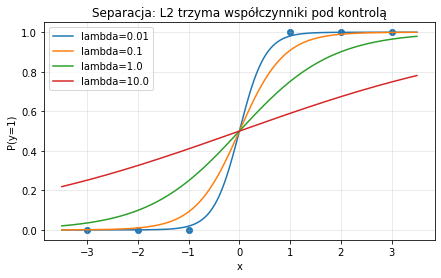

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sep_df['x'], sep_df['y'])
x_grid = np.linspace(-3.5, 3.5, 300)
for lam in [0.01, 0.1, 1.0, 10.0]:
    fit_sep = fit_logistic_irls(X_sep, y_sep, l2=lam, max_iter=80)
    p_grid = sigmoid(fit_sep['beta'][0] + fit_sep['beta'][1]*x_grid)
    ax.plot(x_grid, p_grid, label=f'lambda={lam}')
ax.set_xlabel('x')
ax.set_ylabel('P(y=1)')
ax.set_title('Separacja: L2 trzyma współczynniki pod kontrolą')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 7. Mini-ćwiczenia

### Ćwiczenie A

Jeśli $\ell_{null}=-20$ i $\ell_{full}=-14$, to:

$$
G^2 = 2((-14)-(-20))=12
$$

Jeśli dodaliśmy jeden parametr, porównujemy z $\chi^2_1$.

### Ćwiczenie B

Jeśli $\beta=0.4$, to:

$$
\exp(0.4)\approx 1.49
$$

czyli wzrost predyktora o 1 jednostkę mnoży odds około $1.49$ raza.

### Ćwiczenie C

Jeśli model ma bardzo duże współczynniki i prawdopodobieństwa bliskie $0$ albo $1$, sprawdź, czy nie ma separacji albo zbyt słabej regularizacji.